In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load Titanic dataset exactly once
df = sns.load_dataset("titanic")

# Required offline fallback
df.to_csv("titanic.csv", index=False)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (891, 15)


In [3]:
# Dataset profiling

print("=== DATASET INFO ===")
df.info()

print("\n=== DESCRIPTIVE STATISTICS ===")
display(df.describe(include="all").T)

print("\n=== DATASET SHAPE ===")
print(df.shape)

print("\n=== MISSING VALUES ===")
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100)

missing_report = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": missing_pct
})

display(missing_report[missing_report["Missing_Count"] > 0])

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

=== DESCRIPTIVE STATISTICS ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
sibsp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292
embarked,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,891,3,Third,491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
who,891,3,man,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN



=== DATASET SHAPE ===
(891, 15)

=== MISSING VALUES ===


,Missing_Count,Missing_Percentage
age,177,19.865320
embarked,2,0.224467
deck,688,77.216611
embark_town,2,0.224467


In [4]:
# Missing-value handling
# Apply the required percentage-based threshold rule

# Record missing-value percentages before cleaning
missing_pct = df.isnull().mean() * 100

print("Missing-value percentages before cleaning:")
for column in missing_pct[missing_pct > 0].index:
    print(f"{column}: {missing_pct[column]:.4f}%")

print("\nCleaning decisions:")
print("- age: 19.8653% missing -> 5%-30% range -> median imputation")
print("- embarked: 0.2245% missing -> below 5% -> drop affected rows")
print("- deck: 77.2166% missing -> very high missingness -> drop column")
print("- embark_town: 0.2245% missing -> below 5% -> drop affected rows")

# Work on a copy so the original loaded dataset remains documented
cleaned_df = df.copy()

# Very high missingness: drop deck
cleaned_df = cleaned_df.drop(columns=["deck"])

# 5%-30% missingness: median-impute age
cleaned_df["age"] = cleaned_df["age"].fillna(cleaned_df["age"].median())

# Under 5% missingness: drop rows with missing embarked/embark_town
cleaned_df = cleaned_df.dropna(subset=["embarked", "embark_town"])

print("\n=== CLEANED DATASET ===")
print("Shape:", cleaned_df.shape)
print("\nRemaining missing values:")
display(cleaned_df.isnull().sum()[cleaned_df.isnull().sum() > 0])

print("\nAge median used for imputation:", df["age"].median())

Missing-value percentages before cleaning:
age: 19.8653%
embarked: 0.2245%
deck: 77.2166%
embark_town: 0.2245%

Cleaning decisions:
- age: 19.8653% missing -> 5%-30% range -> median imputation
- embarked: 0.2245% missing -> below 5% -> drop affected rows
- deck: 77.2166% missing -> very high missingness -> drop column
- embark_town: 0.2245% missing -> below 5% -> drop affected rows

=== CLEANED DATASET ===
Shape: (889, 14)

Remaining missing values:


,0



Age median used for imputation: 28.0


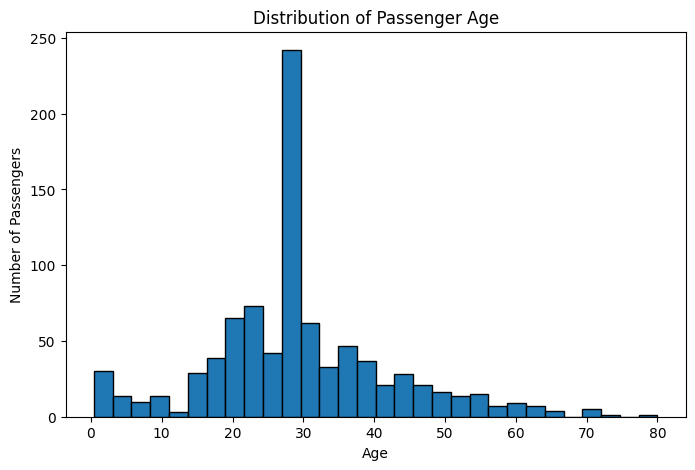

In [5]:
# Age Distribution

plt.figure(figsize=(8, 5))
plt.hist(cleaned_df["age"], bins=30, edgecolor="black")

plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

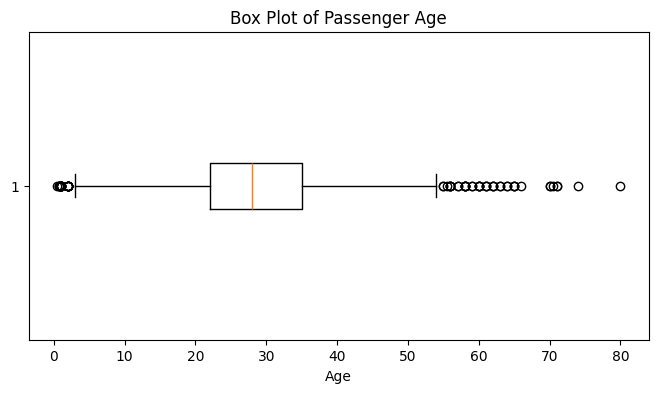

In [6]:
# Age Box Plot

plt.figure(figsize=(8, 4))
plt.boxplot(cleaned_df["age"], vert=False)

plt.title("Box Plot of Passenger Age")
plt.xlabel("Age")

plt.show()

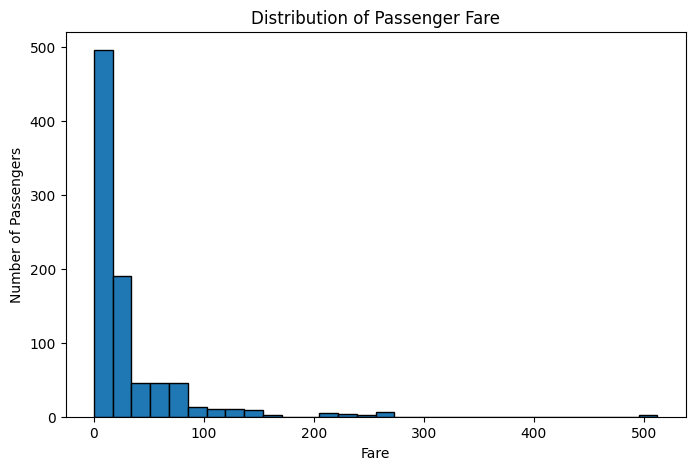

In [7]:
# Fare Distribution

plt.figure(figsize=(8, 5))
plt.hist(cleaned_df["fare"], bins=30, edgecolor="black")

plt.title("Distribution of Passenger Fare")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

plt.show()

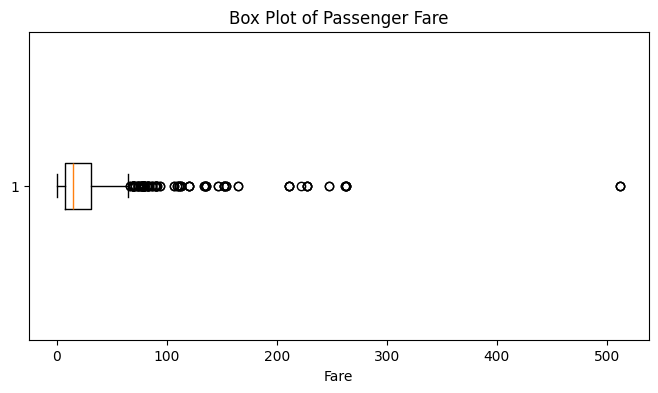

In [8]:
# Fare Box Plot

plt.figure(figsize=(8, 4))
plt.boxplot(cleaned_df["fare"], vert=False)

plt.title("Box Plot of Passenger Fare")
plt.xlabel("Fare")

plt.show()

In [9]:
# Age IQR Outliers

q1_age = cleaned_df["age"].quantile(0.25)
q3_age = cleaned_df["age"].quantile(0.75)

iqr_age = q3_age - q1_age

lower_age = q1_age - 1.5 * iqr_age
upper_age = q3_age + 1.5 * iqr_age

age_outliers = cleaned_df[
    (cleaned_df["age"] < lower_age) |
    (cleaned_df["age"] > upper_age)
]

print("=== AGE IQR OUTLIER ANALYSIS ===")
print(f"Q1: {q1_age:.2f}")
print(f"Q3: {q3_age:.2f}")
print(f"IQR: {iqr_age:.2f}")
print(f"Lower Bound: {lower_age:.2f}")
print(f"Upper Bound: {upper_age:.2f}")
print(f"Number of Age Outliers: {len(age_outliers)}")

=== AGE IQR OUTLIER ANALYSIS ===
Q1: 22.00
Q3: 35.00
IQR: 13.00
Lower Bound: 2.50
Upper Bound: 54.50
Number of Age Outliers: 65


In [10]:
# Fare IQR Outliers

q1_fare = cleaned_df["fare"].quantile(0.25)
q3_fare = cleaned_df["fare"].quantile(0.75)

iqr_fare = q3_fare - q1_fare

lower_fare = q1_fare - 1.5 * iqr_fare
upper_fare = q3_fare + 1.5 * iqr_fare

fare_outliers = cleaned_df[
    (cleaned_df["fare"] < lower_fare) |
    (cleaned_df["fare"] > upper_fare)
]

print("=== FARE IQR OUTLIER ANALYSIS ===")
print(f"Q1: {q1_fare:.2f}")
print(f"Q3: {q3_fare:.2f}")
print(f"IQR: {iqr_fare:.2f}")
print(f"Lower Bound: {lower_fare:.2f}")
print(f"Upper Bound: {upper_fare:.2f}")
print(f"Number of Fare Outliers: {len(fare_outliers)}")

=== FARE IQR OUTLIER ANALYSIS ===
Q1: 7.90
Q3: 31.00
IQR: 23.10
Lower Bound: -26.76
Upper Bound: 65.66
Number of Fare Outliers: 114


In [11]:
# Fare Mean, Median and Mode

fare_mean = cleaned_df["fare"].mean()
fare_median = cleaned_df["fare"].median()
fare_mode = cleaned_df["fare"].mode().iloc[0]

print("=== FARE SUMMARY STATISTICS ===")
print(f"Mean: {fare_mean:.4f}")
print(f"Median: {fare_median:.4f}")
print(f"Mode: {fare_mode:.4f}")

=== FARE SUMMARY STATISTICS ===
Mean: 32.0967
Median: 14.4542
Mode: 8.0500


In [12]:
# Fare Distribution Interpretation

if fare_mean > fare_median > fare_mode:
    print("Fare distribution is right-skewed (positively skewed).")
elif fare_mean < fare_median < fare_mode:
    print("Fare distribution is left-skewed (negatively skewed).")
else:
    print("Fare distribution is approximately symmetric based on mean, median, and mode.")

Fare distribution is right-skewed (positively skewed).


In [13]:
# Survival Rate by Sex

survival_by_sex = cleaned_df.groupby("sex")["survived"].mean()

print("=== SURVIVAL RATE BY SEX ===")
display(survival_by_sex)

=== SURVIVAL RATE BY SEX ===


,survived
sex,
female,0.740385
male,0.188908


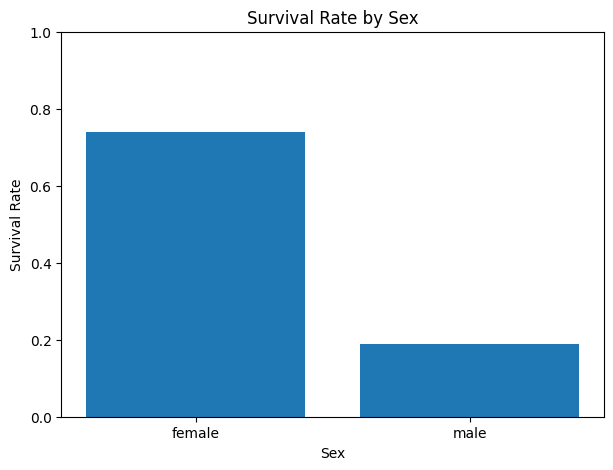

In [14]:
# Survival Rate by Sex Chart

survival_by_sex = cleaned_df.groupby("sex")["survived"].mean()

plt.figure(figsize=(7, 5))
plt.bar(survival_by_sex.index, survival_by_sex.values)

plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")

plt.ylim(0, 1)
plt.show()

In [15]:
# Survival Rate by Passenger Class

survival_by_class = cleaned_df.groupby("pclass")["survived"].mean()

print("=== SURVIVAL RATE BY PASSENGER CLASS ===")
display(survival_by_class)

=== SURVIVAL RATE BY PASSENGER CLASS ===


,survived
pclass,
1,0.626168
2,0.472826
3,0.242363


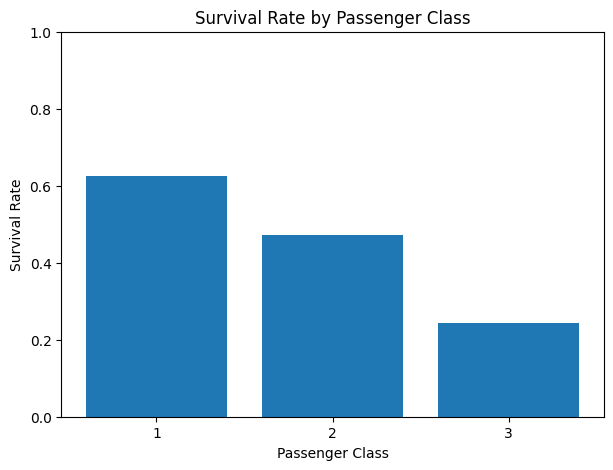

In [16]:
# Survival Rate by Passenger Class Chart

survival_by_class = cleaned_df.groupby("pclass")["survived"].mean()

plt.figure(figsize=(7, 5))
plt.bar(survival_by_class.index.astype(str), survival_by_class.values)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.ylim(0, 1)
plt.show()

In [17]:
# Survival by Sex and Passenger Class

female_first = cleaned_df[
    (cleaned_df["sex"] == "female") & (cleaned_df["pclass"] == 1)
]["survived"].mean()

female_second = cleaned_df[
    (cleaned_df["sex"] == "female") & (cleaned_df["pclass"] == 2)
]["survived"].mean()

female_third = cleaned_df[
    (cleaned_df["sex"] == "female") & (cleaned_df["pclass"] == 3)
]["survived"].mean()

male_first = cleaned_df[
    (cleaned_df["sex"] == "male") & (cleaned_df["pclass"] == 1)
]["survived"].mean()

male_second = cleaned_df[
    (cleaned_df["sex"] == "male") & (cleaned_df["pclass"] == 2)
]["survived"].mean()

male_third = cleaned_df[
    (cleaned_df["sex"] == "male") & (cleaned_df["pclass"] == 3)
]["survived"].mean()

print("=== SURVIVAL RATE BY SEX AND PASSENGER CLASS ===")
print(f"Female - 1st Class: {female_first:.4f}")
print(f"Female - 2nd Class: {female_second:.4f}")
print(f"Female - 3rd Class: {female_third:.4f}")
print(f"Male - 1st Class:   {male_first:.4f}")
print(f"Male - 2nd Class:   {male_second:.4f}")
print(f"Male - 3rd Class:   {male_third:.4f}")

=== SURVIVAL RATE BY SEX AND PASSENGER CLASS ===
Female - 1st Class: 0.9674
Female - 2nd Class: 0.9211
Female - 3rd Class: 0.5000
Male - 1st Class:   0.3689
Male - 2nd Class:   0.1574
Male - 3rd Class:   0.1354


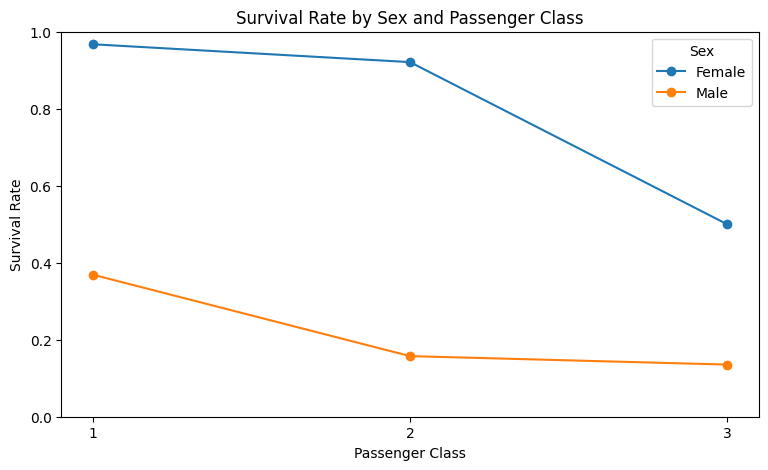

In [18]:
# Survival Rate by Sex and Passenger Class

survival_sex_class = pd.DataFrame({
    "Sex": ["Female", "Female", "Female", "Male", "Male", "Male"],
    "Passenger Class": [1, 2, 3, 1, 2, 3],
    "Survival Rate": [
        female_first,
        female_second,
        female_third,
        male_first,
        male_second,
        male_third
    ]
})

plt.figure(figsize=(9, 5))

for sex in ["Female", "Male"]:
    data = survival_sex_class[survival_sex_class["Sex"] == sex]
    plt.plot(
        data["Passenger Class"],
        data["Survival Rate"],
        marker="o",
        label=sex
    )

plt.title("Survival Rate by Sex and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.xticks([1, 2, 3])
plt.ylim(0, 1)
plt.legend(title="Sex")

plt.show()

In [19]:
# Correlation Matrix

correlation_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

correlation_matrix = cleaned_df[correlation_columns].corr()

print("=== CORRELATION MATRIX ===")
display(correlation_matrix)

=== CORRELATION MATRIX ===


,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.335549,-0.069822,-0.034040,0.083151,0.255290
pclass,-0.335549,1.000000,-0.336512,0.081656,0.016824,-0.548193
age,-0.069822,-0.336512,1.000000,-0.232543,-0.171485,0.093707
sibsp,-0.034040,0.081656,-0.232543,1.000000,0.414542,0.160887
parch,0.083151,0.016824,-0.171485,0.414542,1.000000,0.217532
fare,0.255290,-0.548193,0.093707,0.160887,0.217532,1.000000


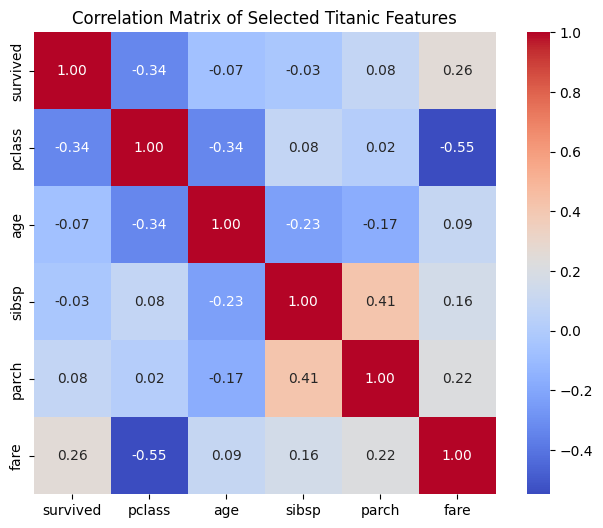

In [20]:
# Correlation Heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)

plt.title("Correlation Matrix of Selected Titanic Features")
plt.show()

In [21]:
# Correlation Interpretation

print("=== STRONGEST CORRELATIONS ===")

print("1. Passenger Class and Fare:")
print("Correlation:", round(correlation_matrix.loc["pclass", "fare"], 4))
print("Interpretation: Passenger class and fare have a moderate negative correlation.")
print("This indicates that the numerical coding of passenger class is associated with fare,")
print("with higher class numbers generally corresponding to lower fares.")

print("\n2. Passenger Class and Age:")
print("Correlation:", round(correlation_matrix.loc["pclass", "age"], 4))
print("Interpretation: Passenger class and age have a moderate negative correlation.")
print("This indicates that passengers in higher-numbered classes tended to be younger")
print("than passengers in lower-numbered classes in this dataset.")

=== STRONGEST CORRELATIONS ===
1. Passenger Class and Fare:
Correlation: -0.5482
Interpretation: Passenger class and fare have a moderate negative correlation.
This indicates that the numerical coding of passenger class is associated with fare,
with higher class numbers generally corresponding to lower fares.

2. Passenger Class and Age:
Correlation: -0.3365
Interpretation: Passenger class and age have a moderate negative correlation.
This indicates that passengers in higher-numbered classes tended to be younger
than passengers in lower-numbered classes in this dataset.


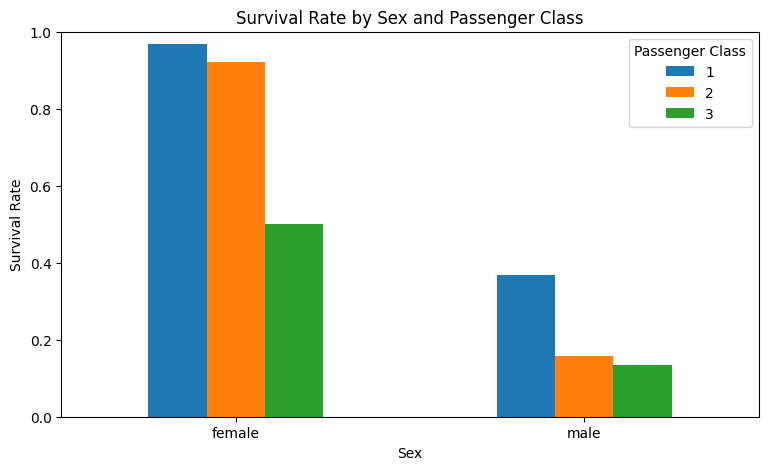

In [22]:
# Multivariate Survival Analysis

survival_sex_class_plot = (
    cleaned_df
    .groupby(["sex", "pclass"])["survived"]
    .mean()
    .unstack()
)

survival_sex_class_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Survival Rate by Sex and Passenger Class")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Passenger Class")

plt.show()

Female passengers had higher survival rates than male passengers across all three passenger classes. Among female passengers, survival was highest in first class and lowest in third class. Male passengers had substantially lower survival rates overall, with the lowest survival rate in third class. This shows that sex and passenger class together provide a clearer picture of survival than either variable alone.

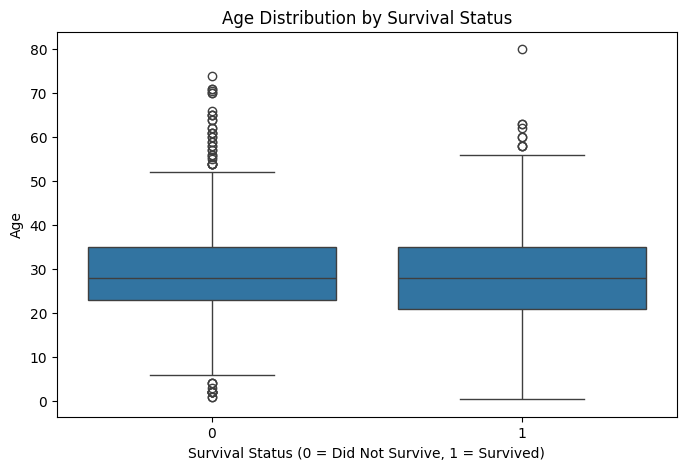

In [23]:
# Age Distribution by Survival

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=cleaned_df,
    x="survived",
    y="age"
)

plt.title("Age Distribution by Survival Status")
plt.xlabel("Survival Status (0 = Did Not Survive, 1 = Survived)")
plt.ylabel("Age")

plt.show()

The box plot shows that the age distributions of survivors and non-survivors overlap considerably. This indicates that age alone does not clearly separate the two survival outcomes. The variation in age suggests that other factors, such as sex and passenger class, also played an important role in survival.

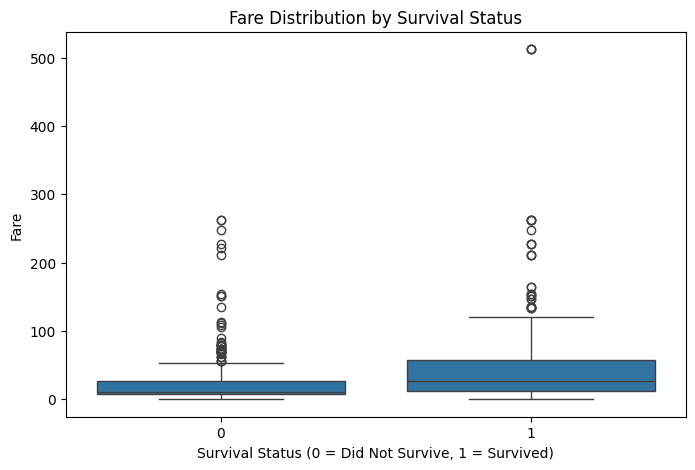

In [24]:
# Fare Distribution by Survival

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=cleaned_df,
    x="survived",
    y="fare"
)

plt.title("Fare Distribution by Survival Status")
plt.xlabel("Survival Status (0 = Did Not Survive, 1 = Survived)")
plt.ylabel("Fare")

plt.show()

The box plot shows that passengers who survived generally had higher fare values than passengers who did not survive. The survivor group also contains several high-fare observations, indicating greater variation in fares among survivors. This pattern is consistent with the earlier finding that passenger class and fare are related to survival.

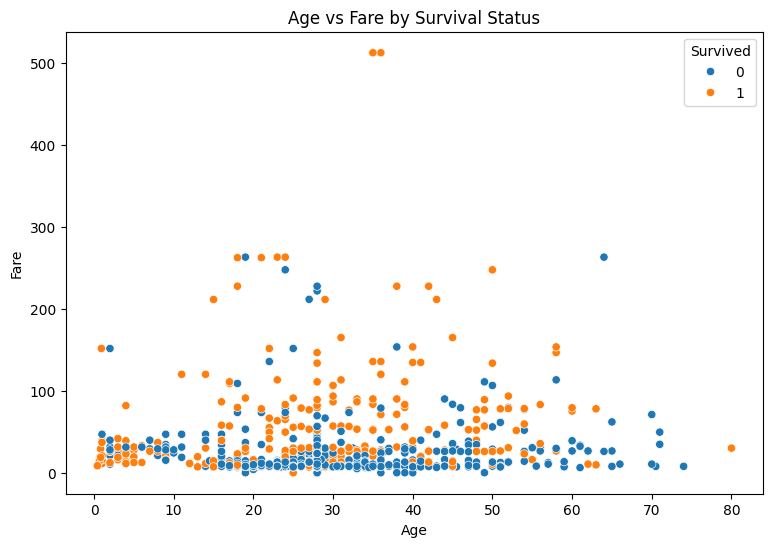

In [25]:
# Age vs Fare by Survival

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=cleaned_df,
    x="age",
    y="fare",
    hue="survived"
)

plt.title("Age vs Fare by Survival Status")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.legend(title="Survived")

plt.show()

The scatter plot shows that fare values vary substantially across passenger ages and survival outcomes. Higher-fare passengers appear more frequently among survivors, although there is considerable overlap between the two groups. This indicates that fare and age together provide additional context for survival, but neither variable alone clearly determines the outcome.

In [26]:
# Standardize Age and Fare

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cleaned_df[["age_standardized", "fare_standardized"]] = scaler.fit_transform(
    cleaned_df[["age", "fare"]]
)

print("=== STANDARDIZED DATA SUMMARY ===")
print("Age standardized mean:", cleaned_df["age_standardized"].mean())
print("Age standardized std:", cleaned_df["age_standardized"].std())

print("\nFare standardized mean:", cleaned_df["fare_standardized"].mean())
print("Fare standardized std:", cleaned_df["fare_standardized"].std())

=== STANDARDIZED DATA SUMMARY ===
Age standardized mean: 2.717486278497571e-16
Age standardized std: 1.000562904632249

Fare standardized mean: 1.3987061727561027e-16
Fare standardized std: 1.0005629046322495


In [27]:
# Before and After Standardization

standardization_summary = pd.DataFrame({
    "Feature": ["Age", "Fare"],
    "Original Mean": [
        cleaned_df["age"].mean(),
        cleaned_df["fare"].mean()
    ],
    "Original Std": [
        cleaned_df["age"].std(),
        cleaned_df["fare"].std()
    ],
    "Standardized Mean": [
        cleaned_df["age_standardized"].mean(),
        cleaned_df["fare_standardized"].mean()
    ],
    "Standardized Std": [
        cleaned_df["age_standardized"].std(),
        cleaned_df["fare_standardized"].std()
    ]
})

display(standardization_summary)

,Feature,Original Mean,Original Std,Standardized Mean,Standardized Std
0,Age,29.315152,12.984932,2.717486e-16,1.000563
1,Fare,32.096681,49.697504,1.398706e-16,1.000563


Standardization transformed both age and fare to approximately zero mean and unit standard deviation. Age changed from a mean of 29.32 and standard deviation of 12.98 to approximately 0 and 1, while fare changed from a mean of 32.10 and standard deviation of 49.70 to approximately 0 and 1. This confirms that the z-score standardization was applied correctly for exploratory analysis.